In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from hamiltonian_bulk import Hfull

e = 1.602e-19 # Elementary charge in Coulombs
hbar = 1.05457e-34 # Reduced Planck constant in J·s
m0 = me = 9.109e-31 # Electron rest mass in kg
a0 = 5.292e-11 # Bohr radius in meters
# switch = int(input("Enter kinetic energy: "))
# energy_scale = 27.2113862 * hbar **2 / m0 / a0**2  # Conversion factor from hbar^2/m_e/a_0^2 to eV

params_coupling_m = {
    "p_perp": 0.4829 * hbar / a0/(e*1e-10),
    "p_parallel": 0.6431 * hbar / a0/(e*1e-10),
    "A_c2_perp": 4.1565 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_c1_perp": 9.5120 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_c2_parallel": 2.4091 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_c1_parallel": 1 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_1": -4.3636 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_2": -2.0833 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_3": 2.4545 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_4": -2.7504 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_5": -2.7232 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_6": -3.5421 * hbar**2 / (2 * m0)/(e*1e-20),
    "Delta_1": 0.2688 ,
    "Delta_2": 0.0934 ,
    "Delta_3": 0.0908 ,
    "Ecbp1": 0.632 ,
    "Ecb": 0.298 ,
    "Ev": -0.3622 ,
    "hbar": hbar,
    "m0": m0,
}

params_coupling_p = {
    "p_perp": 0.4829 * hbar / a0/(e*1e-10),
    "p_parallel": 0.6431 * hbar / a0/(e*1e-10),
    "A_c2_perp": 4.1565 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_c1_perp": 9.5120 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_c2_parallel": 2.4091 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_c1_parallel": 1 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_1": -4.3636 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_2": -2.0833 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_3": 2.4545 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_4": -2.7504 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_5": 2.7232 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_6": -3.5421 * hbar**2 / (2 * m0)/(e*1e-20),
    "Delta_1": 0.2688 ,
    "Delta_2": 0.0934 ,
    "Delta_3": 0.0908 ,
    "Ecbp1": 0.632 ,
    "Ecb": 0.298 ,
    "Ev": -0.3622 ,
    "hbar": hbar,
    "m0": m0,
}

118
345
kp bands shape: (345, 10)
kp bands shape: (345, 10)


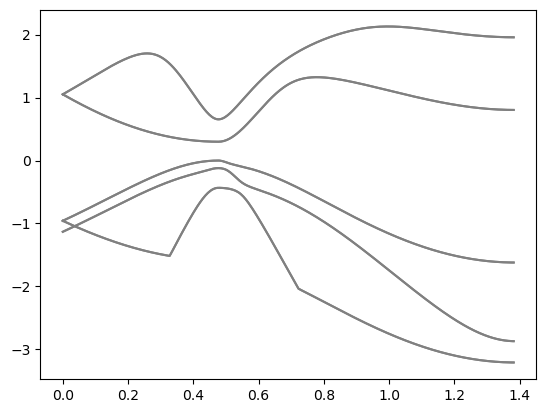

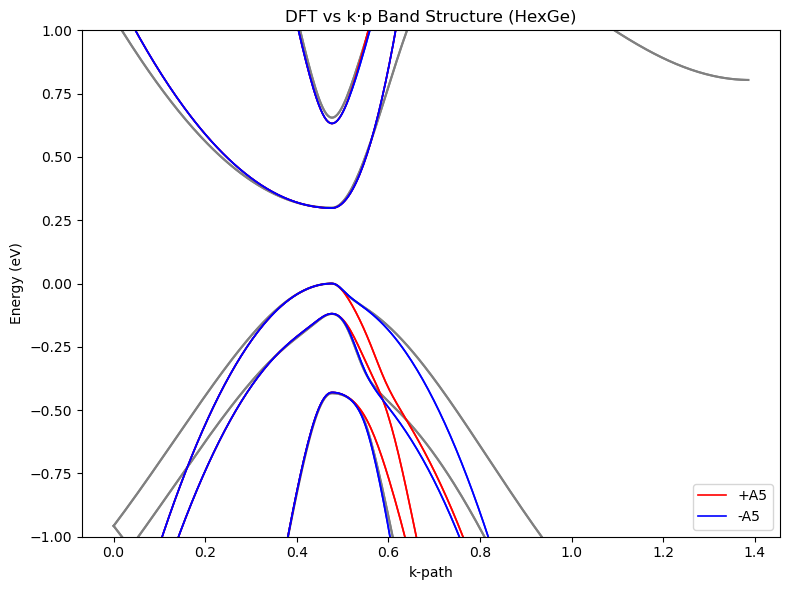

In [6]:

# =========================================================
# 1. LOAD DFT BAND STRUCTURE
# =========================================================

data = np.loadtxt("HexGe.dat")

Nb = 148
Nk = 465

bands = []
for n in range(Nb):
    band = data[n * Nk : (n + 1) * Nk]
    bands.append(band)

bands = np.array(bands)


# =========================================================
# 2. EXTRACT LOW-ENERGY BANDS
# =========================================================

shift = 0.031404
band_data = []

# Save 10 low-energy bands with alternating direction
for n in range(50, 60):
    if n % 2 == 0:
        # EVEN: Forward order
        for i in range(0, Nk):
            k_val = bands[n, i, 0]
            energy = bands[n, i, 1] + shift
            band_data.append([k_val, energy])
    else:
        # ODD: Reverse order
        for i in range(Nk - 1, -1, -1):
            k_val = bands[n, i, 0]
            energy = bands[n, i, 1] + shift
            band_data.append([k_val, energy])

band_data = np.array(band_data)
np.savetxt("HexGe_band_data.dat", band_data)


# =========================================================
# 3. HIGH-SYMMETRY POINTS
# =========================================================

g_point = np.argmin(band_data[7 * Nk : (7 + 1) * Nk, 1])
M_point = 345

print(g_point)
print(M_point)

num_bands = 10


# =========================================================
# 4. PLOT DFT BANDS (CHECK)
# =========================================================

for i in range(num_bands):
    start = i * Nk
    end = start + M_point

    plt.plot(
        band_data[start:end, 0],
        band_data[start:end, 1],
        linestyle='-',
        color='gray'
    )


# =========================================================
# 5. DEFINE k·p PATH
# =========================================================

a = 3.99
c = 6.59

kpoints_z = np.linspace(np.pi / c, 0, g_point + 1)
kx_vals = np.linspace(0, np.pi / a, M_point - len(kpoints_z))

kpath_z = np.array([[0, 0, kz] for kz in kpoints_z])

kpath_xy = np.array([
    [kx, -kx / np.sqrt(3), 0]
    for kx in kx_vals
])

kpath_full = np.concatenate([kpath_z, kpath_xy])


# =========================================================
# 6. COMPUTE k-DISTANCE
# =========================================================

k_dist = np.zeros(len(kpath_full))

for i in range(1, len(kpath_full)):
    dk = np.linalg.norm(kpath_full[i] - kpath_full[i - 1])
    k_dist[i] = k_dist[i - 1] + dk


# =========================================================
# 7. COMPUTE k·p BANDS
# =========================================================

evaldata_p = []

for k in kpath_full:
    H = Hfull(k[0], k[1], k[2], p=params_coupling_p)
    evals, evec = eigh(H)
    evaldata_p.append(evals)

evaldata_p = np.array(evaldata_p)

print("kp bands shape:", evaldata_p.shape)


evaldata_m = []

for k in kpath_full:
    H = Hfull(k[0], k[1], k[2], p=params_coupling_m)
    evals, evec = eigh(H)
    evaldata_m.append(evals)

evaldata_m = np.array(evaldata_m)

print("kp bands shape:", evaldata_m.shape)


# =========================================================
# 8. PLOT DFT + k·p (FULL)
# =========================================================

plt.figure(figsize=(8, 6))

# ---- DFT bands ----
for i in range(num_bands):
    start = i * Nk
    end = start + M_point

    plt.plot(
        k_dist,
        band_data[start:end, 1],
        linestyle='-',
        color='gray'
    )

# ---- k·p bands ----
for n in range(evaldata_p.shape[1]):
    plt.plot(
        k_dist,
        evaldata_p[:, n],
        color='red',
        linewidth=1.2,
        label="+A5" if n == 0 else None
    )



for n in range(evaldata_m.shape[1]):
    plt.plot(
        k_dist,
        evaldata_m[:, n],
        color='blue',
        linewidth=1.2,
        label="-A5" if n == 0 else None
    )


plt.legend()
plt.ylim(-1, 1)
plt.xlabel("k-path")
plt.ylabel("Energy (eV)")
plt.title("DFT vs k·p Band Structure (HexGe)")
plt.tight_layout()
plt.savefig("HexGe_DFT_vs_kp.png", dpi=300)
plt.show()


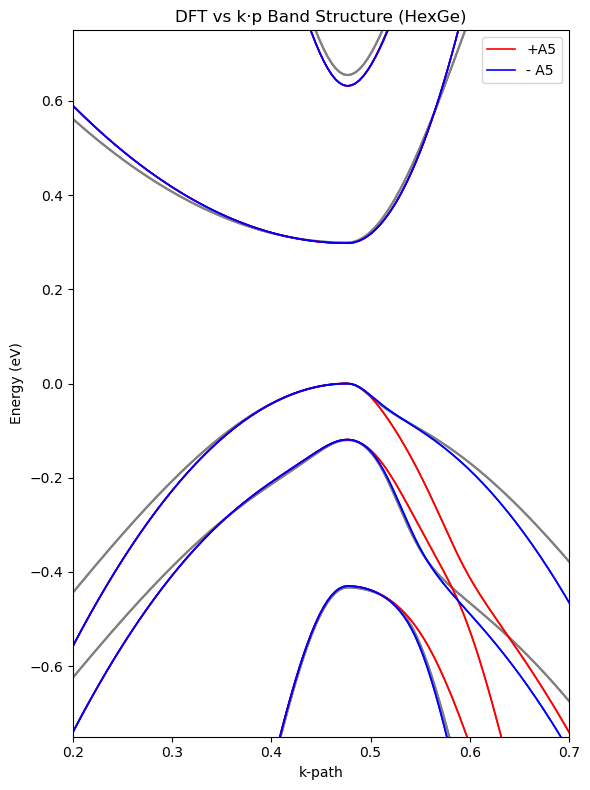

In [7]:


# =========================================================
# 9. PLOT DFT + k·p (ZOOMED)
# =========================================================

plt.figure(figsize=(6, 8))

# ---- DFT bands ----
for i in range(num_bands):
    start = i * Nk
    end = start + M_point

    plt.plot(
        k_dist,
        band_data[start:end, 1],
        linestyle='-',
        color='gray'
    )

# ---- k·p bands ----
for n in range(evaldata_p.shape[1]):
    plt.plot(
        k_dist,
        evaldata_p[:, n],
        color='red',
        linewidth=1.2,
        label="+A5" if n == 0 else None
    )
for n in range(evaldata_m.shape[1]):
    plt.plot(
        k_dist,
        evaldata_m[:, n],
        color='blue',
        linewidth=1.2,
        label="- A5" if n == 0 else None
    )

plt.legend()
plt.ylim(-0.75, 0.75)
plt.xlim(0.2, 0.7)
plt.xlabel("k-path")
plt.ylabel("Energy (eV)")
plt.title("DFT vs k·p Band Structure (HexGe)")
plt.tight_layout()
plt.savefig("HexGe_DFT_vs_kp_zoomed.png", dpi=300)
plt.show()
